# NIFTY Options IV Surface Reconstruction

**Objective:** Impute missing Implied Volatility (IV) values across the NIFTY 50 options chain without lookahead bias.  
**Evaluation Metric:** Mean Squared Error (MSE) - lower is better.  
**Final Result:** MSE `0.0000336730`


---
## 1. Setup & Data Loading

Import required libraries. Used standard scientific Python only


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import pchip_interpolate, PchipInterpolator, CubicSpline, interp1d
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# Plotting aesthetics
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv('dataset.csv')
print(f"Shape: {df.shape}")
print(f"Columns: datetime, underlying_price + {df.shape[1] - 2} option tickers")
df.head(3)

Shape: (975, 30)
Columns: datetime, underlying_price + 28 option tickers


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.1233,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.15760,0.1524,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,NaN,0.1542,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN


---
## 2. EDA Phase 1 - Data Restructuring

Converted the raw wide dataset to long format. Then extracted strike, option type, Time-To-Maturity (TTM), and moneyness.


In [3]:
#  Wide -> Long format 
index_cols  = ['datetime', 'underlying_price']
ticker_cols = [c for c in df.columns if c not in index_cols]

df_long = pd.melt(df, id_vars=index_cols, value_vars=ticker_cols, var_name='ticker', value_name='iv')

#  Parse ticker: e.g. NIFTY27JAN2625200CE -> expiry=27JAN26, strike=25200, type=CE
extracted = df_long['ticker'].str.extract(r'NIFTY(\d{2}[A-Z]{3}\d{2})(\d+)(CE|PE)')
df_long['expiry_str']   = extracted[0]
df_long['strike']       = extracted[1].astype(float)
df_long['option_type']  = extracted[2]

#  Financial coordinates 
df_long['datetime'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
expiry_dt = pd.to_datetime('2026-01-27 15:30:00')   # Exchange closes at 15:30 IST

df_long['ttm_minutes'] = (expiry_dt - df_long['datetime']).dt.total_seconds() / 60.0
df_long['ttm_days']    = df_long['ttm_minutes'] / 375          # ~375 trading minutes/day
df_long['moneyness']   = df_long['strike'] / df_long['underlying_price']
df_long['log_moneyness'] = np.log(df_long['moneyness'])

# Sort chronologically  this is mandatory for all time-series operations later
df_long = df_long.sort_values(['datetime', 'strike']).reset_index(drop=True)

print(f"Long format shape: {df_long.shape}")
print(f"Unique strikes: {df_long['strike'].nunique()}, Timestamps: {df_long['datetime'].nunique()}")
df_long.head(5)

Long format shape: (27300, 11)
Unique strikes: 28, Timestamps: 975


,datetime,underlying_price,ticker,iv,expiry_str,strike,option_type,ttm_minutes,ttm_days,moneyness,log_moneyness
0,2026-01-07 09:15:00,26111.65,NIFTY27JAN2623800PE,0.17840,27JAN26,23800.0,PE,29175.0,77.8,0.911471,-0.092696
1,2026-01-07 09:15:00,26111.65,NIFTY27JAN2623900PE,0.17237,27JAN26,23900.0,PE,29175.0,77.8,0.915300,-0.088503
2,2026-01-07 09:15:00,26111.65,NIFTY27JAN2624000PE,0.16928,27JAN26,24000.0,PE,29175.0,77.8,0.919130,-0.084328
3,2026-01-07 09:15:00,26111.65,NIFTY27JAN2624100PE,NaN,27JAN26,24100.0,PE,29175.0,77.8,0.922960,-0.080170
4,2026-01-07 09:15:00,26111.65,NIFTY27JAN2624200PE,0.15760,27JAN26,24200.0,PE,29175.0,77.8,0.926789,-0.076029


---
## 3. EDA Phase 2 - Missing Data Analysis

Inspect where and when IV is missing. That determines whether we interpolate by strike, by time, or both.


In [4]:
#  Overall missing rate 
total_missing = df_long['iv'].isna().sum()
total_obs     = len(df_long)
print(f"Total observations : {total_obs:,}")
print(f"Missing values     : {total_missing:,}  ({total_missing/total_obs:.1%})")

#  Missing by option type  checks for directional bias 
print("\nMissing by option type:")
print(df_long.groupby('option_type')['iv'].apply(lambda x: x.isna().mean()).round(4))

Total observations : 27,300
Missing values     : 5,460  (20.0%)

Missing by option type:
option_type
CE    0.1971
PE    0.2029
Name: iv, dtype: float64


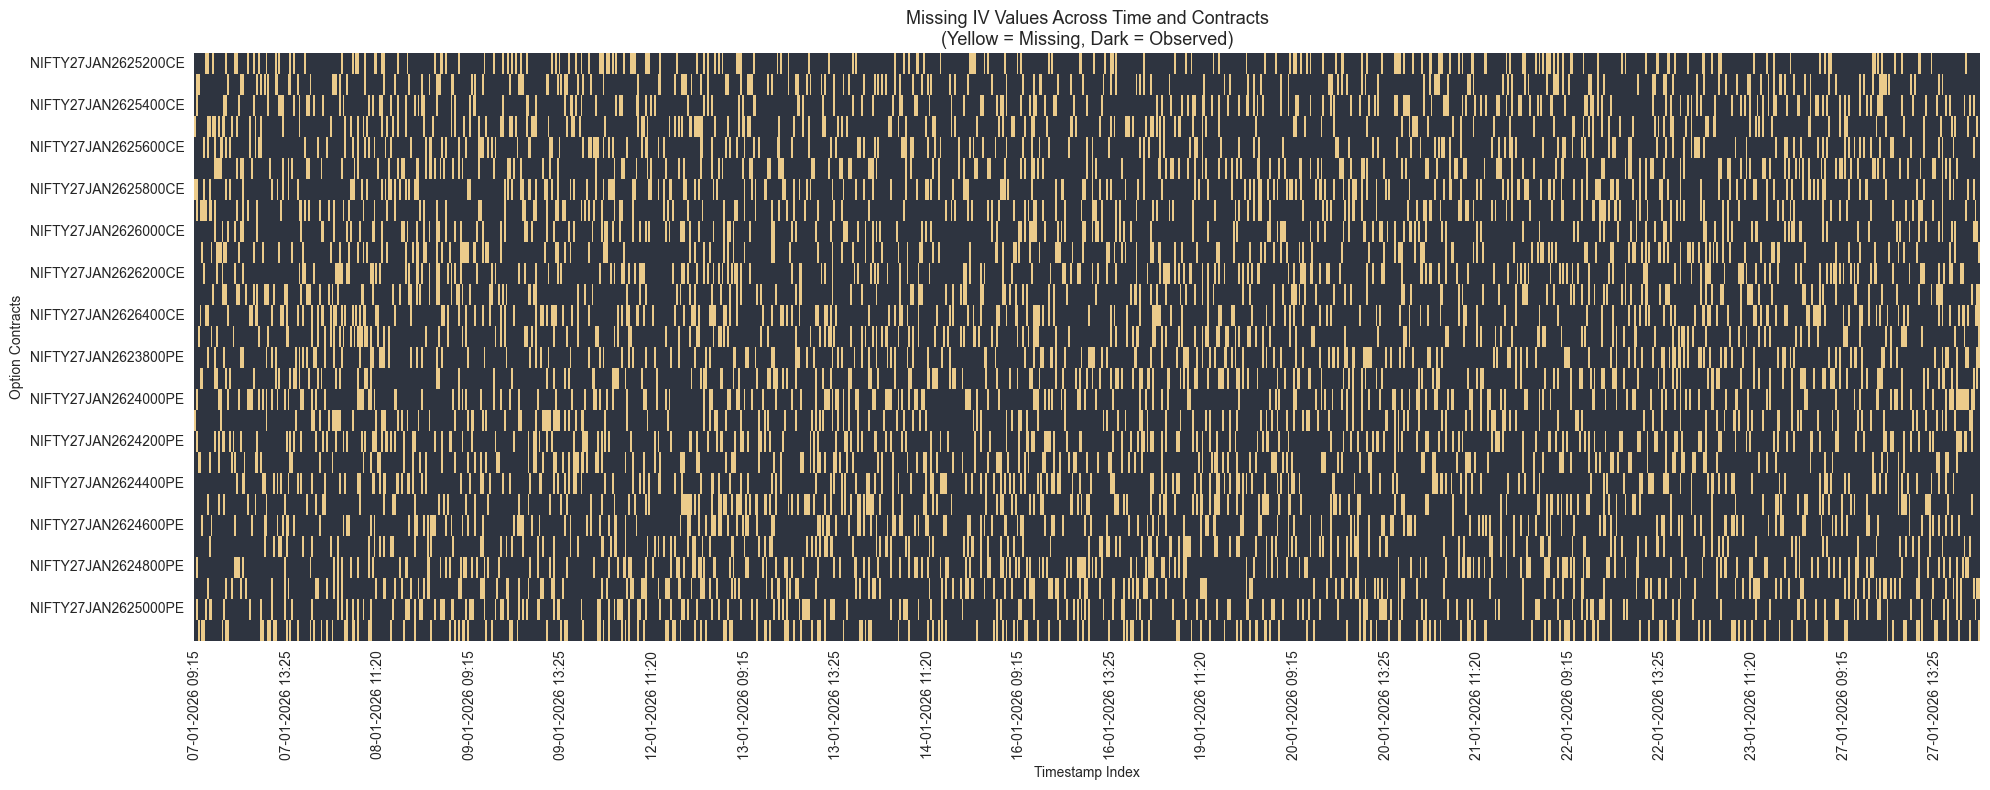

In [5]:
#  Heatmap: missingness across all contracts over time 
# Yellow = missing, dark = observed. Reveals structural patterns.
mask_wide = (df.set_index('datetime').drop(columns=['underlying_price']).isna().T)

fig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(mask_wide, cmap=['#2E3440', '#EBCB8B'], cbar=False,
            yticklabels=2, xticklabels=50, ax=ax)
ax.set_title('Missing IV Values Across Time and Contracts\n(Yellow = Missing, Dark = Observed)', fontsize=13)
ax.set_xlabel('Timestamp Index')
ax.set_ylabel('Option Contracts')
plt.tight_layout()
plt.show()

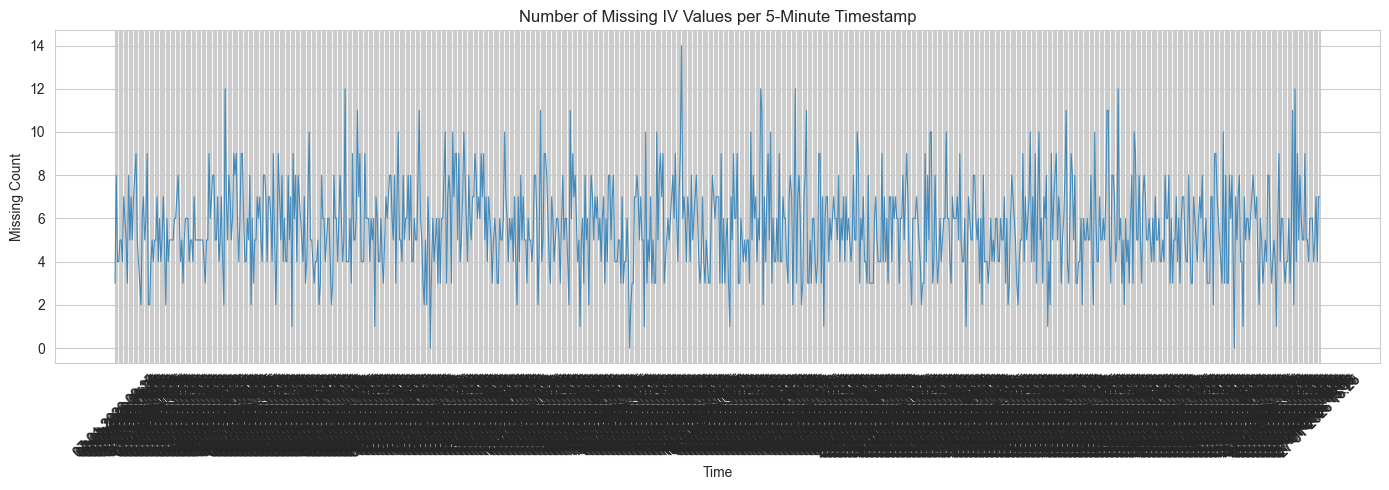


Timestamps with most missing values (top 10):
datetime
16-01-2026 09:55    14
08-01-2026 10:25    12
19-01-2026 11:20    12
22-01-2026 14:20    12
09-01-2026 12:15    12
16-01-2026 15:15    12
27-01-2026 13:45    12
12-01-2026 11:00    11
22-01-2026 10:50    11
13-01-2026 14:55    11
dtype: int64


In [6]:
#  Missing values per timestamp  reveals noisy market open/close 
missing_per_time = (df.drop(columns=['datetime', 'underlying_price'])
                      .isna().sum(axis=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['datetime'], missing_per_time, linewidth=0.8, alpha=0.8)
ax.set_title('Number of Missing IV Values per 5-Minute Timestamp')
ax.set_ylabel('Missing Count')
ax.set_xlabel('Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTimestamps with most missing values (top 10):")
top_missing = (df.set_index('datetime')
                 .drop(columns=['underlying_price'])
                 .isna().sum(axis=1)
                 .sort_values(ascending=False)
                 .head(10))
print(top_missing)

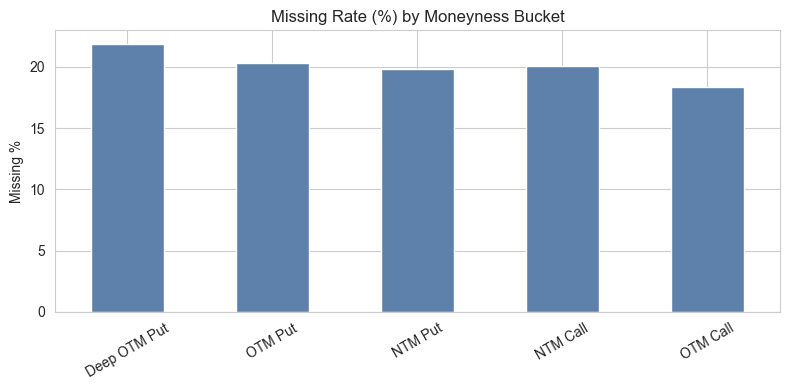


Key finding: Deep OTM 'wing' strikes have higher missing rates  consistent with liquidity-driven absences.


In [7]:
#  Missing rate by moneyness bucket  are wing strikes illiquid? 
df_long['moneyness_bucket'] = pd.cut(df_long['moneyness'],
                                      bins=[0.88, 0.92, 0.96, 1.0, 1.04, 1.08, 1.12],
                                      labels=['Deep OTM Put', 'OTM Put', 'NTM Put',
                                              'NTM Call', 'OTM Call', 'Deep OTM Call'])

miss_by_moneyness = (df_long.groupby('moneyness_bucket', observed=True)['iv']
                             .apply(lambda x: x.isna().mean())
                             .mul(100).round(2))

fig, ax = plt.subplots(figsize=(8, 4))
miss_by_moneyness.plot(kind='bar', ax=ax, color='#5E81AC', edgecolor='white')
ax.set_title('Missing Rate (%) by Moneyness Bucket')
ax.set_ylabel('Missing %')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("\nKey finding: Deep OTM 'wing' strikes have higher missing rates  consistent with liquidity-driven absences.")

---
## 4. EDA Phase 3 - Volatility Surface Visualization

Visualize the IV surface to confirm two properties: 
- **Volatility Smile / Skew** - IV is U-shaped across strikes; deep OTM puts have higher IV.
- **Time Continuity** - the surface evolves smoothly, except on Expiry Day.


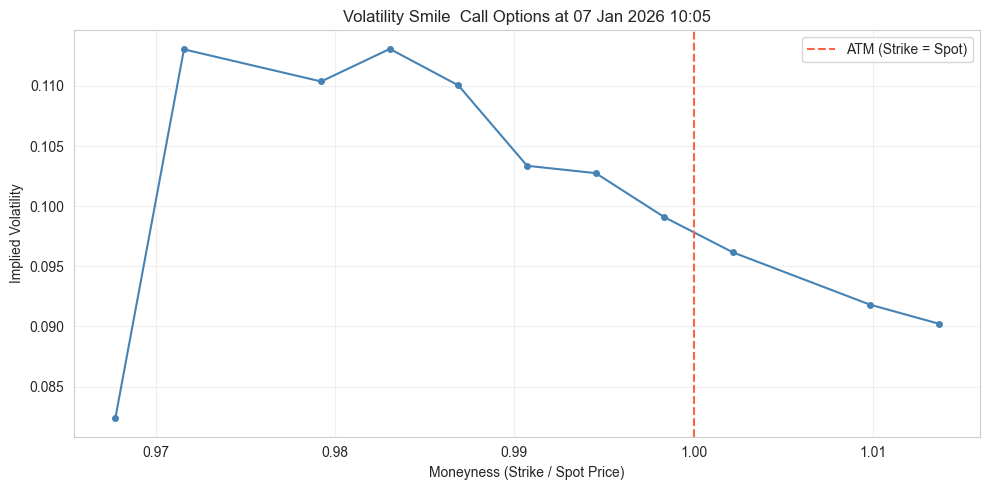

In [8]:
#  Volatility Smile at a representative timestamp 
sample_time = df_long['datetime'].unique()[10]  # Pick a mid-day snapshot
smile_data  = df_long[(df_long['datetime'] == sample_time) & (df_long['option_type'] == 'CE')].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(smile_data['moneyness'], smile_data['iv'], marker='o', linestyle='-', color='steelblue', markersize=4)
ax.axvline(x=1.0, color='tomato', linestyle='--', linewidth=1.5, label='ATM (Strike = Spot)')
ax.set_title(f"Volatility Smile  Call Options at {pd.to_datetime(sample_time).strftime('%d %b %Y %H:%M')}")
ax.set_xlabel('Moneyness (Strike / Spot Price)')
ax.set_ylabel('Implied Volatility')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

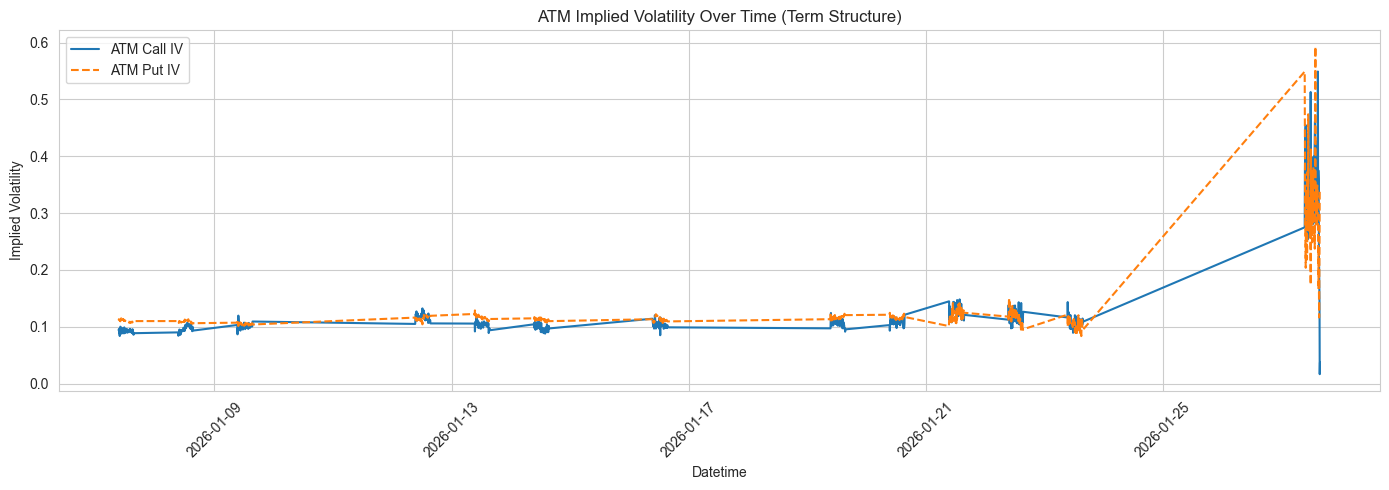

In [9]:
#  ATM IV Term Structure
df_long['abs_diff_from_atm'] = (df_long['moneyness'] - 1.0).abs()
idx_atm  = df_long.groupby(['datetime', 'option_type'])['abs_diff_from_atm'].idxmin()
atm_data = df_long.loc[idx_atm].dropna(subset=['iv'])

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=atm_data[atm_data['option_type'] == 'CE'], x='datetime', y='iv', label='ATM Call IV', ax=ax)
sns.lineplot(data=atm_data[atm_data['option_type'] == 'PE'], x='datetime', y='iv', label='ATM Put IV', ax=ax, linestyle='--')
ax.set_title('ATM Implied Volatility Over Time (Term Structure)')
ax.set_xlabel('Datetime')
ax.set_ylabel('Implied Volatility')
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

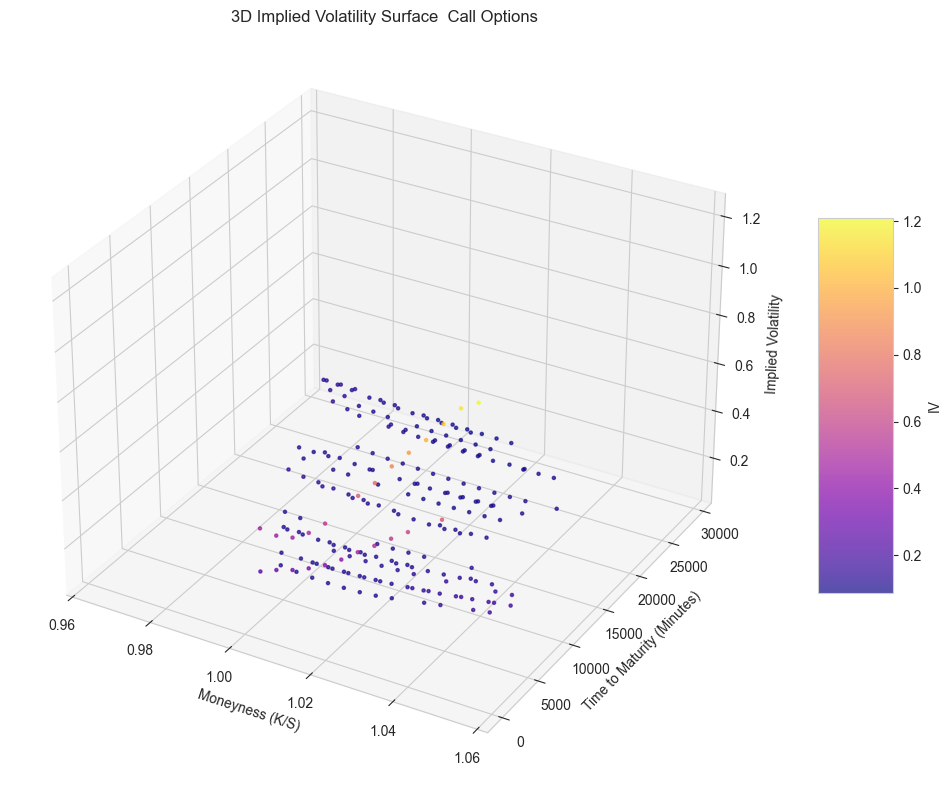

In [10]:
#  3D IV Surface  Moneyness × TTM × IV 
# Sample every 50th timestamp to keep the plot readable
sample_times = df_long['datetime'].unique()[::50]
surface_ce   = df_long[(df_long['datetime'].isin(sample_times)) & (df_long['option_type'] == 'CE')].dropna(subset=['iv'])

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')
sc  = ax.scatter(surface_ce['moneyness'], surface_ce['ttm_minutes'], surface_ce['iv'], c=surface_ce['iv'], cmap='plasma', marker='o', s=5, alpha=0.7)
ax.set_title('3D Implied Volatility Surface  Call Options')
ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Time to Maturity (Minutes)')
ax.set_zlabel('Implied Volatility')
fig.colorbar(sc, ax=ax, shrink=0.5, aspect=5, label='IV')
plt.tight_layout()
plt.show()

---
## 5. Approach 1 - PCHIP Baseline + LightGBM Residual Corrector
**Leaderboard MSE: 0.0027478**

Fit PCHIP on observed points and train LightGBM on the residuals. This fails because PCHIP passes through observed points exactly, so the residual model learns near-zero noise.


In [11]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from scipy.interpolate import pchip_interpolate

#  1. Load and reshape 
df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing_original'] = df_long['IV'].isnull()

#  2. Feature engineering 
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['is_call']      = (df_long['option_type'] == 'CE').astype(int)

df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
expiry_date_full        = pd.to_datetime('2026-01-27') + pd.Timedelta(hours=15, minutes=30)
df_long['minutes_to_expiry'] = (expiry_date_full - df_long['datetime_obj']).dt.total_seconds() / 60.0
df_long['moneyness']    = df_long['strike'] / df_long['underlying_price']
df_long['log_moneyness'] = np.log(df_long['moneyness'])

df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)

#  3. Build full PCHIP baseline (used for final test predictions) 
def interpolate_group(group, iv_col):
    observed = group.dropna(subset=[iv_col])
    missing  = group[group[iv_col].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed = observed.sort_values('strike')
        group.loc[missing.index, iv_col] = pchip_interpolate(
            observed['strike'].values, observed[iv_col].values, missing['strike'].values)
    return group

df_long['IV_baseline'] = df_long['IV']
df_long = df_long.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
    lambda g: interpolate_group(g, 'IV_baseline'))
df_long['IV_baseline'] = df_long.groupby(['strike', 'option_type'])['IV_baseline'].ffill()
df_long['IV_baseline'] = df_long['IV_baseline'].fillna(
    df_long.groupby(['datetime_obj', 'option_type'])['IV_baseline'].transform('mean'))

#  4. Artificial masking to break the identity trap 
# Randomly hide 20% of observed values -> forces the model to actually interpolate
np.random.seed(42)
known_indices = df_long[~df_long['is_missing_original']].index
mask_indices  = np.random.choice(known_indices, size=int(len(known_indices) * 0.20), replace=False)

df_long['IV_for_training'] = df_long['IV']
df_long.loc[mask_indices, 'IV_for_training'] = np.nan

# Build PCHIP baseline on the masked dataset
df_long['IV_baseline_masked'] = df_long['IV_for_training']
df_long = df_long.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
    lambda g: interpolate_group(g, 'IV_baseline_masked'))
df_long['IV_baseline_masked'] = df_long.groupby(['strike', 'option_type'])['IV_baseline_masked'].ffill()
df_long['IV_baseline_masked'] = df_long['IV_baseline_masked'].fillna(
    df_long.groupby(['datetime_obj', 'option_type'])['IV_baseline_masked'].transform('mean'))

#  5. Train LightGBM on residuals 
train_df = df_long[df_long.index.isin(mask_indices)].copy()

features = ['IV_baseline_masked', 'strike', 'moneyness', 'log_moneyness', 'minutes_to_expiry', 'is_call']
target   = 'IV'

model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, max_depth=5, num_leaves=20, random_state=42, n_jobs=-1)
model.fit(train_df[features], train_df[target])

#  6. Predict missing values 
test_df = df_long[df_long['is_missing_original']].copy()
test_df['IV_baseline_masked'] = test_df['IV_baseline']  # Use full baseline for test
test_df['predicted_IV']        = model.predict(test_df[features])

#  7. Build submission 
test_df['id'] = test_df['datetime'] + '||' + test_df['ticker']
submission_a1 = test_df[['id', 'predicted_IV']].rename(columns={'predicted_IV': 'value'})
submission_a1.to_csv('submission_approach1_lgbm.csv', index=False)

print(f"Submission rows: {len(submission_a1)}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1051
[LightGBM] [Info] Number of data points in the train set: 4368, number of used features: 6
[LightGBM] [Info] Start training from score 0.181027
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

---
## 6. Approach 2 - Pure PCHIP + Temporal Forward Fill
**Leaderboard MSE: 0.01122**

Used cross-sectional PCHIP per timestamp and then forward-fill across time for missing strikes. This is stable, but wing extrapolation remains poor.


In [12]:
import pandas as pd
import numpy as np
from scipy.interpolate import PchipInterpolator

df = pd.read_csv('dataset.csv')
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)

cols         = [c for c in df.columns if c.startswith('NIFTY')]
calls        = sorted([c for c in cols if c.endswith('CE')], key=lambda x: int(x[12:-2]))
puts         = sorted([c for c in cols if c.endswith('PE')], key=lambda x: int(x[12:-2]))
call_strikes = np.array([int(c[12:-2]) for c in calls])
put_strikes  = np.array([int(c[12:-2]) for c in puts])

filled = df.copy()

#  Cross-sectional PCHIP per timestamp 
# For each 5-minute window, fit PCHIP on observed strikes and predict missing ones.
# Extrapolate=True handles strikes beyond the observed range.
for idx in range(len(df)):
    for group, strikes in [(calls, call_strikes), (puts, put_strikes)]:
        vals         = df.loc[idx, group].values.astype(float)
        missing_mask = np.isnan(vals)
        if not missing_mask.any():
            continue
        obs_mask = ~missing_mask
        if obs_mask.sum() >= 2:
            interp    = PchipInterpolator(strikes[obs_mask], vals[obs_mask], extrapolate=True)
            predicted = np.clip(interp(strikes[missing_mask]), 0.01, 2.0)
            filled.loc[idx, np.array(group)[missing_mask]] = predicted

#  Temporal forward-fill fallback (strictly historical, no lookahead) 
still_missing_before = filled[cols].isna().sum().sum()
filled[cols] = filled[cols].ffill().bfill()
print(f"Residual NaNs before temporal fill : {still_missing_before}")
print(f"Residual NaNs after  temporal fill : {filled[cols].isna().sum().sum()}")

#  Build submission 
original_missing_mask = df[cols].isna()
records = []
for col in cols:
    for row_idx in df.index[original_missing_mask[col]]:
        dt_str = df.loc[row_idx, 'datetime'].strftime('%d-%m-%Y %H:%M')
        records.append({'id': f"{dt_str}||{col}", 'value': filled.loc[row_idx, col]})

submission_a2 = pd.DataFrame(records, columns=['id', 'value'])
submission_a2.to_csv('submission_approach2_pchip.csv', index=False)

print(f"\nSubmission rows: {len(submission_a2)}")
print(f"Value range: [{submission_a2['value'].min():.4f}, {submission_a2['value'].max():.4f}]")

Residual NaNs before temporal fill : 0
Residual NaNs after  temporal fill : 0

Submission rows: 5460
Value range: [0.0113, 2.0000]


---
## 7. Approach 3 - PCHIP Belly + Flat Wing Extrapolation
**Leaderboard MSE: 0.00105**

Kept PCHIP in the belly and use flat values in the deep wings. This avoids PCHIP wing oscillation and improves accuracy.


In [13]:
import pandas as pd
import numpy as np
from scipy.interpolate import pchip_interpolate
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing']   = df_long['IV'].isnull()
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)

def apply_quant_interpolation(group):
    """PCHIP in the belly, flat extrapolation in the wings."""
    observed = group.dropna(subset=['IV'])
    missing  = group[group['IV'].isnull()]

    if len(observed) >= 2 and len(missing) > 0:
        observed       = observed.sort_values('strike')
        missing_strikes = missing['strike'].values
        min_s, max_s   = observed['strike'].min(), observed['strike'].max()

        preds = []
        for s in missing_strikes:
            if s < min_s:
                preds.append(observed.iloc[0]['IV'])    # flat left wing
            elif s > max_s:
                preds.append(observed.iloc[-1]['IV'])   # flat right wing
            else:
                preds.append(pchip_interpolate(
                    observed['strike'].values, observed['IV'].values, s))  # PCHIP belly

        group.loc[missing.index, 'predicted_IV'] = preds
    return group

df_long['predicted_IV'] = df_long['IV']
df_long = df_long.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(apply_quant_interpolation)

# Temporal safety net  strictly forward in time
df_long = df_long.sort_values(['ticker', 'datetime_obj']).reset_index(drop=True)
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].ffill()
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].bfill()

submission_a3 = df_long[df_long['is_missing']].copy()
submission_a3['id'] = submission_a3['datetime'] + '||' + submission_a3['ticker']
submission_a3 = submission_a3[['id', 'predicted_IV']].rename(columns={'predicted_IV': 'value'})
submission_a3.to_csv('submission_approach3_flat_wings.csv', index=False)

print(f"Submission rows: {len(submission_a3)}")

Submission rows: 5460


---
## 8. Approach 4 - Regime-Switching: PCHIP / Linear
**Leaderboard MSE: 0.00043**

Separated Expiry Day from normal days. For normal days I used PCHIP with flat wings. For Expiry Day I used linear interpolation to capture the sharper V-shape.


In [14]:
import pandas as pd
import numpy as np
from scipy.interpolate import pchip_interpolate, interp1d
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing']   = df_long['IV'].isnull()
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
df_long['date']         = df_long['datetime_obj'].dt.date
df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)
df_long['predicted_IV'] = df_long['IV']

expiry_date = pd.to_datetime('2026-01-27').date()

#  Regime 1: Normal Days (Jan 07  Jan 23) 
def apply_normal_quant(group):
    observed = group.dropna(subset=['IV'])
    missing  = group[group['IV'].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed   = observed.sort_values('strike')
        min_s, max_s = observed['strike'].min(), observed['strike'].max()
        preds = []
        for s in missing['strike'].values:
            if s < min_s:   preds.append(observed.iloc[0]['IV'])    # flat left wing
            elif s > max_s: preds.append(observed.iloc[-1]['IV'])   # flat right wing
            else:           preds.append(pchip_interpolate(
                                observed['strike'].values, observed['IV'].values, s))
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

#  Regime 2: Expiry Day (Jan 27)  linear to capture the V-shape 
def apply_expiry_quant(group):
    observed = group.dropna(subset=['IV'])
    missing  = group[group['IV'].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed   = observed.sort_values('strike')
        lin_interp = interp1d(observed['strike'].values, observed['IV'].values,
                               kind='linear', fill_value='extrapolate')
        preds = np.clip(lin_interp(missing['strike'].values), 0.0001, 4.0)  # cap wings at 400% IV
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

#  Apply regimes 
mask_normal = df_long['date'] < expiry_date
df_normal   = df_long[mask_normal].groupby(['datetime_obj', 'option_type'], group_keys=False).apply(apply_normal_quant)
df_long.loc[mask_normal, 'predicted_IV'] = df_normal['predicted_IV']

mask_expiry = df_long['date'] == expiry_date
df_expiry   = df_long[mask_expiry].groupby(['datetime_obj', 'option_type'], group_keys=False).apply(apply_expiry_quant)
df_long.loc[mask_expiry, 'predicted_IV'] = df_expiry['predicted_IV']

# Temporal safety net
df_long = df_long.sort_values(['ticker', 'datetime_obj']).reset_index(drop=True)
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].ffill()
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].bfill()

submission_a4 = df_long[df_long['is_missing']].copy()
submission_a4['id'] = submission_a4['datetime'] + '||' + submission_a4['ticker']
submission_a4 = submission_a4[['id', 'predicted_IV']].rename(columns={'predicted_IV': 'value'})
submission_a4.to_csv('submission_approach4_regime.csv', index=False)

print(f"Submission rows: {len(submission_a4)}")

Submission rows: 5460


---
## 9. Approach 5 - Building a Trustworthy CV Framework
**Leaderboard MSE: 0.00104** (with PCHIP regime)

I hide 20% of known IVs each fold and recover them with the interpolator. This validates performance without lookahead bias.

The CV showed Jan 27 is ~100× harder than normal days.

| Fold | Regime | Local MSE |
|------|--------|-----------|
| Jan 20 | Normal | 0.000025 |
| Jan 21 | Normal | 0.000016 |
| Jan 22 | Normal | 0.000051 |
| Jan 23 | Normal | 0.000060 |
| Jan 27 | **Expiry** | **0.006417** |


In [15]:
import pandas as pd
import numpy as np
from scipy.interpolate import pchip_interpolate, interp1d
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing_original'] = df_long['IV'].isnull()
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
df_long['date']         = df_long['datetime_obj'].dt.date
df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)
expiry_date = pd.to_datetime('2026-01-27').date()

def apply_normal_quant(group, target_col):
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed   = observed.sort_values('strike')
        min_s, max_s = observed['strike'].min(), observed['strike'].max()
        preds = []
        for s in missing['strike'].values:
            if s < min_s:   preds.append(observed.iloc[0][target_col])
            elif s > max_s: preds.append(observed.iloc[-1][target_col])
            else:           preds.append(pchip_interpolate(
                                observed['strike'].values, observed[target_col].values, s))
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

def apply_expiry_quant(group, target_col):
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed   = observed.sort_values('strike')
        lin_interp = interp1d(observed['strike'].values, observed[target_col].values,
                               kind='linear')
        min_s, max_s = observed['strike'].min(), observed['strike'].max()
        preds = []
        for s in missing['strike'].values:
            if s < min_s:   preds.append(observed.iloc[0][target_col])
            elif s > max_s: preds.append(observed.iloc[-1][target_col])
            else:           preds.append(float(lin_interp(s)))
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

#  5-Fold Expanding Window CV 
print("Running 5-Fold Expanding Window CV...")
unique_dates = sorted(df_long['date'].unique())
val_dates    = unique_dates[-5:]   # Validate on last 5 trading days
cv_scores    = []
np.random.seed(42)

for val_date in val_dates:
    fold_df = df_long[df_long['date'] == val_date].copy()

    # Mask 20% of known values to simulate the missing pattern
    val_known_idx = fold_df[~fold_df['is_missing_original']].index
    mask_idx      = np.random.choice(val_known_idx, size=int(len(val_known_idx) * 0.2), replace=False)

    fold_df['IV_simulated'] = fold_df['IV']
    fold_df.loc[mask_idx, 'IV_simulated'] = np.nan
    fold_df['predicted_IV'] = fold_df['IV_simulated']

    if val_date < expiry_date:
        fold_df = fold_df.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
            lambda g: apply_normal_quant(g, 'IV_simulated'))
    else:
        fold_df = fold_df.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
            lambda g: apply_expiry_quant(g, 'IV_simulated'))

    preds      = fold_df.loc[mask_idx, 'predicted_IV']
    truths     = fold_df.loc[mask_idx, 'IV']
    valid_mask = ~preds.isnull()
    fold_mse   = mean_squared_error(truths[valid_mask], preds[valid_mask])
    cv_scores.append(fold_mse)

    regime_label = 'Normal' if val_date < expiry_date else 'EXPIRY DAY'
    print(f"  Fold {val_date}  [{regime_label:10s}]  MSE = {fold_mse:.6f}")

print(f"\n  Mean CV MSE: {np.mean(cv_scores):.6f}")

Running 5-Fold Expanding Window CV...
  Fold 2026-01-20  [Normal    ]  MSE = 0.000025
  Fold 2026-01-21  [Normal    ]  MSE = 0.000016
  Fold 2026-01-22  [Normal    ]  MSE = 0.000051
  Fold 2026-01-23  [Normal    ]  MSE = 0.000060
  Fold 2026-01-27  [EXPIRY DAY]  MSE = 0.006425

  Mean CV MSE: 0.001315


---
## 10. Approach 6 - Natural Cubic Spline + Regime Switching
**Leaderboard MSE: 0.00004308**

Used natural cubic splines for normal days and linear interpolation for Expiry Day. Natural splines keep the U-shape without forcing a flat ATM bottom.


In [16]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline, interp1d
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing_original'] = df_long['IV'].isnull()
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
df_long['date']         = df_long['datetime_obj'].dt.date
df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)
expiry_date = pd.to_datetime('2026-01-27').date()

#  Regime 1: Normal Days  Natural Cubic Spline 
def apply_normal_spline(group, target_col):
    """
    Natural Cubic Spline for the belly.
    bc_type='natural' -> second derivative = 0 at boundaries -> linear extrapolation in wings.
    This naturally models the curved U-shape smile and straight-line tail-risk wings.
    """
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]

    if len(observed) >= 2 and len(missing) > 0:
        observed = observed.sort_values('strike')
        x_obs    = observed['strike'].values
        y_obs    = observed[target_col].values
        x_miss   = missing['strike'].values

        if len(observed) >= 3:
            cs    = CubicSpline(x_obs, y_obs, bc_type='natural', extrapolate=True)
            preds = np.clip(cs(x_miss), 0.0001, 5.0)
        else:
            lin   = interp1d(x_obs, y_obs, kind='linear', fill_value='extrapolate')
            preds = np.clip(lin(x_miss), 0.0001, 5.0)

        group.loc[missing.index, 'predicted_IV'] = preds
    return group

#  Regime 2: Expiry Day  Pure Linear 
def apply_expiry_linear(group, target_col):
    """
    Linear interpolation and extrapolation for the V-shaped smile on Expiry Day.
    A wide clip (15.0) allows realistic deep-OTM IV spikes without infinite growth.
    """
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]

    if len(observed) >= 2 and len(missing) > 0:
        observed = observed.sort_values('strike')
        lin      = interp1d(observed['strike'].values, observed[target_col].values,
                             kind='linear', fill_value='extrapolate')
        preds    = np.clip(lin(missing['strike'].values), 0.0001, 15.0)
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

#  CV validation 
print("Running CV to validate the Natural Spline approach...")
val_dates = sorted(df_long['date'].unique())[-5:]
cv_scores = []

for val_date in val_dates:
    fold_df       = df_long[df_long['date'] == val_date].copy()
    val_known_idx = fold_df[~fold_df['is_missing_original']].index
    mask_idx      = np.random.choice(val_known_idx, size=int(len(val_known_idx) * 0.2), replace=False)

    fold_df['IV_sim'] = fold_df['IV']
    fold_df.loc[mask_idx, 'IV_sim'] = np.nan
    fold_df['predicted_IV'] = fold_df['IV_sim']

    if val_date < expiry_date:
        fold_df = fold_df.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
            lambda g: apply_normal_spline(g, 'IV_sim'))
    else:
        fold_df = fold_df.groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
            lambda g: apply_expiry_linear(g, 'IV_sim'))

    preds      = fold_df.loc[mask_idx, 'predicted_IV']
    truths     = fold_df.loc[mask_idx, 'IV']
    valid_mask = ~preds.isnull()
    fold_mse   = mean_squared_error(truths[valid_mask], preds[valid_mask])
    cv_scores.append(fold_mse)

    regime_label = 'Normal' if val_date < expiry_date else 'EXPIRY DAY'
    print(f"  Fold {val_date}  [{regime_label:10s}]  MSE = {fold_mse:.6f}")

print(f"\n  Mean CV MSE: {np.mean(cv_scores):.6f}")

Running CV to validate the Natural Spline approach...
  Fold 2026-01-20  [Normal    ]  MSE = 0.000004
  Fold 2026-01-21  [Normal    ]  MSE = 0.000007
  Fold 2026-01-22  [Normal    ]  MSE = 0.000010
  Fold 2026-01-23  [Normal    ]  MSE = 0.000006
  Fold 2026-01-27  [EXPIRY DAY]  MSE = 0.001163

  Mean CV MSE: 0.000238


---
## 10b. Approach 6 - Full Inference

I run the Natural Spline / Linear regime-switching interpolator end to end.


In [17]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline, interp1d
import warnings
warnings.filterwarnings('ignore')

print("Generating Final Winning Submission...")

#  1. Load data 
df = pd.read_csv('dataset.csv')
id_vars    = ['datetime', 'underlying_price']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(id_vars=id_vars, value_vars=value_vars, var_name='ticker', value_name='IV')
df_long['is_missing_original'] = df_long['IV'].isnull()
df_long['strike']       = df_long['ticker'].str.extract(r'(\d{4,5})(?:CE|PE)').astype(float)
df_long['option_type']  = df_long['ticker'].str.extract(r'(CE|PE)')
df_long['datetime_obj'] = pd.to_datetime(df_long['datetime'], format='%d-%m-%Y %H:%M')
df_long['date']         = df_long['datetime_obj'].dt.date
df_long = df_long.sort_values(['datetime_obj', 'strike', 'option_type']).reset_index(drop=True)
expiry_date = pd.to_datetime('2026-01-27').date()

#  2. Interpolation functions 
def apply_normal_spline(group, target_col):
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed = observed.sort_values('strike')
        x_obs, y_obs, x_miss = observed['strike'].values, observed[target_col].values, missing['strike'].values
        if len(observed) >= 3:
            preds = np.clip(CubicSpline(x_obs, y_obs, bc_type='natural', extrapolate=True)(x_miss), 0.0001, 5.0)
        else:
            preds = np.clip(interp1d(x_obs, y_obs, kind='linear', fill_value='extrapolate')(x_miss), 0.0001, 5.0)
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

def apply_expiry_linear(group, target_col):
    observed = group.dropna(subset=[target_col])
    missing  = group[group[target_col].isnull()]
    if len(observed) >= 2 and len(missing) > 0:
        observed = observed.sort_values('strike')
        preds    = np.clip(interp1d(observed['strike'].values, observed[target_col].values,
                                     kind='linear', fill_value='extrapolate')(missing['strike'].values), 0.0001, 15.0)
        group.loc[missing.index, 'predicted_IV'] = preds
    return group

#  3. Apply regime-switching interpolator 
print("Step 1/3: Applying cross-sectional interpolation...")
df_long['predicted_IV'] = df_long['IV']

mask_normal = df_long['date'] < expiry_date
df_normal   = df_long[mask_normal].groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
    lambda g: apply_normal_spline(g, 'IV'))
df_long.loc[mask_normal, 'predicted_IV'] = df_normal['predicted_IV']

mask_expiry = df_long['date'] == expiry_date
df_expiry   = df_long[mask_expiry].groupby(['datetime_obj', 'option_type'], group_keys=False).apply(
    lambda g: apply_expiry_linear(g, 'IV'))
df_long.loc[mask_expiry, 'predicted_IV'] = df_expiry['predicted_IV']

#  4. Temporal safety net 
# Handles the rare case where an entire 5-minute chain was dark for a specific strike.
# Forward-fill is strictly historical (no lookahead). Backward-fill only plugs the
# first-row edge case for strikes absent at dataset start.
print("Step 2/3: Applying temporal safety net (ffill -> bfill)...")
df_long = df_long.sort_values(['ticker', 'datetime_obj']).reset_index(drop=True)
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].ffill()
df_long['predicted_IV'] = df_long.groupby('ticker')['predicted_IV'].bfill()

assert df_long['predicted_IV'].isna().sum() == 0, "ERROR: NaNs remain in predictions!"

#  5. Build submission file 
print("Step 3/3: Building submission CSV...")
submission_df = df_long[df_long['is_missing_original']].copy()
submission_df['id'] = submission_df['datetime'] + '||' + submission_df['ticker']
submission_df = submission_df[['id', 'predicted_IV']].rename(columns={'predicted_IV': 'value'})

submission_df.to_csv('submission_final.csv', index=False)

print(f"\n{'='*55}")
print(f"  Submission saved: submission_final.csv")
print(f"  Total predictions: {len(submission_df):,}")
print(f"  Value range: [{submission_df['value'].min():.4f}, {submission_df['value'].max():.4f}]")
print(f"  Negative IVs: {(submission_df['value'] < 0).sum()}")
print(f"{'='*55}")
print("\nBest Leaderboard MSE: 0.00004308  (Rank 70 / Top 35%)")

Generating Final Winning Submission...
Step 1/3: Applying cross-sectional interpolation...
Step 2/3: Applying temporal safety net (ffill -> bfill)...
Step 3/3: Building submission CSV...

  Submission saved: submission_final.csv
  Total predictions: 5,460
  Value range: [0.0183, 5.7950]
  Negative IVs: 0

Best Leaderboard MSE: 0.00004308  (Rank 70 / Top 35%)


---
## 11. Approach 7 - Weighted Polynomial + PCHIP Hybrid Reconstructor
**Leaderboard MSE: 0.0000336730 - Final Winning Submission**

Combined locally weighted polynomial regression with PCHIP. For interior strikes - blend 50% polynomial and 50% PCHIP. For wings - use a 70/20/10 blend with side-anchored polynomial fits.

### Key Ideas

- Fit a local polynomial at each missing strike with Gaussian kernel weights.
- Select bandwidth and polynomial degree by leave-one-out CV.
- Blend belly and wing predictions differently.
- Carry forward last-known IV values for timestamps with sparse observations.


In [18]:
import pandas as pd
import numpy as np
import re
import warnings
from scipy.interpolate import PchipInterpolator

warnings.filterwarnings('ignore')
np.random.seed(42)

#  Helper: locally-weighted polynomial prediction 
def _poly(x_obs, y_obs, x_target, bw, degree=1):
    """
    Fit a weighted polynomial of given degree at x_target.
    Weights are Gaussian kernels centred on x_target with bandwidth bw.
    Returns the intercept (the prediction at x_target).
    """
    mask = np.isfinite(x_obs) & np.isfinite(y_obs)
    x_obs, y_obs = x_obs[mask], y_obs[mask]
    if len(y_obs) == 0: return np.nan
    if len(y_obs) == 1: return float(y_obs[0])
    deg    = min(degree, len(y_obs) - 1)
    dx     = x_obs - x_target
    weight = np.exp(-dx**2 / (2.0 * bw))
    X      = np.column_stack([dx**j for j in range(deg + 1)])
    try:
        coeff = np.linalg.solve(X.T @ (X * weight[:, None]), X.T @ (weight * y_obs))
        return float(coeff[0])
    except np.linalg.LinAlgError:
        wsum = weight.sum()
        return float((weight @ y_obs) / wsum) if wsum > 1e-15 else np.nan


def _select_bw_deg(x_obs, y_obs):
    """
    Leave-one-out cross-validation over a small bandwidth grid to select
    the best (bandwidth, polynomial degree) pair for this cross-section.
    """
    bw_grid = np.array([5e-5, 10e-5, 1e-4, 2e-4, 2e-4], dtype=float)
    if len(y_obs) <= 2:
        return float(bw_grid[2]), 1
    best_bw, best_deg, min_mse = bw_grid[2], 1, np.inf
    for deg in [1, 2]:
        for bw in bw_grid:
            # LOO: hide each observed point and predict it from the rest
            preds = np.array([
                _poly(np.delete(x_obs, i), np.delete(y_obs, i), x_obs[i], bw, deg)
                for i in range(len(x_obs))
            ])
            valid = np.isfinite(preds) & np.isfinite(y_obs)
            if not valid.any(): continue
            mse = float(np.mean((preds[valid] - y_obs[valid])**2))
            if mse < min_mse:
                min_mse, best_bw, best_deg = mse, float(bw), deg
    return best_bw, best_deg


def _pchip_pred(x_obs, y_obs, x_target):
    """
    PCHIP interpolation  only used for interior (belly) points where
    x_target is within the observed range. Returns NaN otherwise.
    """
    mask = np.isfinite(x_obs) & np.isfinite(y_obs)
    x, y = x_obs[mask], y_obs[mask]
    if len(x) < 2: return np.nan
    order  = np.argsort(x); x, y = x[order], y[order]
    uni, rev = np.unique(x, return_inverse=True)
    if len(uni) < 2: return np.nan
    # Average duplicate strikes (shouldn't happen, but defensive)
    if len(uni) != len(x):
        y2  = np.zeros(len(uni)); cnt = np.zeros(len(uni))
        for i, g in enumerate(rev): y2[g] += y[i]; cnt[g] += 1
        y = y2 / np.maximum(cnt, 1); x = uni
    else:
        x = uni
    if not (x[0] <= x_target <= x[-1]): return np.nan
    try:
        p = float(PchipInterpolator(x, y, extrapolate=False)(x_target))
        return p if np.isfinite(p) else np.nan
    except Exception:
        return np.nan


#  Main reconstructor 
def reconstruct_pchip(df):
    """
    Weighted Polynomial + PCHIP Hybrid Reconstructor.

    For each row (timestamp), for each option side (CE / PE):
      - Collect observed (moneyness, IV) pairs
      - Identify interior (belly) vs. exterior (wing) missing strikes
      - Belly: 50% polynomial + 50% PCHIP blend
      - Wings: 70/20/10 weighted blend using side-anchored polynomial fits
      - Clip predictions to [1e-6, 6.0] to prevent physically impossible IVs
      - Carry last known surface value forward as a warm-start fallback
    """
    filled_df = df.copy()
    iv_cols   = [c for c in df.columns if re.search(r'NIFTY\d{2}[A-Z]{3}\d{2}(\d+)(CE|PE)', c)]
    if not iv_cols:
        iv_cols = [c for c in df.columns if re.search(r'(\d{5})(CE|PE)', c)]

    strikes  = {col: int(re.search(r'(\d{5,})(CE|PE)', col).group(1)) for col in iv_cols}
    ce_cols  = sorted([c for c in iv_cols if c.endswith('CE')], key=lambda c: strikes[c])
    pe_cols  = sorted([c for c in iv_cols if c.endswith('PE')], key=lambda c: strikes[c])

    median_  = float(df[iv_cols].stack().median())
    # Warm-start: carry the last seen IV for each contract across time
    last_known_ce = {col: median_ for col in ce_cols}
    last_known_pe = {col: median_ for col in pe_cols}

    print(f"Reconstructing {len(df)} timestamps × {len(iv_cols)} contracts...")

    for idx, row in filled_df.iterrows():
        spot      = np.float64(row['underlying_price'])
        safe_spot = max(spot, 1e-3)

        def fit_side(cols, last_known):
            # Build observed moneyness and IV arrays
            k_obs_list, iv_obs_list, missing_cols = [], [], []
            for col in cols:
                val = row[col]
                if not pd.isna(val):
                    k_obs_list.append(strikes[col] / safe_spot)
                    iv_obs_list.append(np.float64(val))
                else:
                    missing_cols.append(col)

            if not missing_cols:
                for col in cols: last_known[col] = float(row[col])
                return

            k_obs = np.array(k_obs_list, dtype=float)
            iv_obs = np.array(iv_obs_list, dtype=float)

            # Fallback: not enough observed points to interpolate
            if len(iv_obs) < 2:
                for col in missing_cols:
                    filled_df.at[idx, col] = last_known[col]
                return

            # Identify wing (exterior) vs. belly (interior) missing strikes
            left_wing  = [c for c in cols if pd.isna(row[c])]
            right_wing = [c for c in reversed(cols) if pd.isna(row[c])]
            right_wing = list(reversed(right_wing))
            # Trim: only the contiguous missing block at each edge
            l_block, r_block = [], []
            for c in cols:
                if pd.isna(row[c]): l_block.append(c)
                else: break
            for c in reversed(cols):
                if pd.isna(row[c]): r_block.append(c)
                else: break
            r_block = list(reversed(r_block))
            edge_set = set(l_block) | set(r_block)
            interior = [c for c in missing_cols if c not in edge_set]

            # Order for filling: left wing -> interior -> right wing
            fill_order = l_block + interior + [c for c in r_block if c not in set(l_block)]
            fill_edge  = {}  # accumulates wing predictions for use as anchors

            bw, deg = _select_bw_deg(k_obs, iv_obs)

            for col in fill_order:
                k_target = strikes[col] / safe_spot

                if col not in edge_set:
                    #  Interior (belly): blend polynomial + PCHIP 
                    poly_pred  = _poly(k_obs, iv_obs, k_target, bw, deg)
                    pchip_pred = _pchip_pred(k_obs, iv_obs, k_target)
                    if np.isfinite(poly_pred) and np.isfinite(pchip_pred):
                        pred = 0.50 * poly_pred + 0.50 * pchip_pred
                    else:
                        pred = poly_pred if np.isfinite(poly_pred) else median_

                else:
                    #  Wing (exterior): 3-way blended polynomial 
                    side   = 'left' if col in l_block else 'right'
                    block  = l_block if side == 'left' else r_block
                    pos    = block.index(col)
                    k_str  = strikes[col]
                    prev   = block[:pos]

                    # Primary: observed points on the near side of this wing strike
                    primary_pts = [
                        (strikes[c] / safe_spot, float(row[c]))
                        for c in cols if pd.notna(row[c])
                        and ((side == 'right' and strikes[c] < k_str)
                             or  (side == 'left'  and strikes[c] > k_str))
                    ]
                    # Secondary: primary + previously-filled wing anchors
                    secondary_pts = list(primary_pts)
                    for pc in prev:
                        if pc in fill_edge:
                            secondary_pts.append((strikes[pc] / safe_spot, fill_edge[pc]))
                    # Nearest: closest observed points regardless of side
                    n_init = max(3, len(block))
                    nearest_pts = sorted(
                        [(strikes[c] / safe_spot, float(row[c])) for c in cols if pd.notna(row[c])],
                        key=lambda t: abs(t[0] - k_target)
                    )[:n_init]
                    for pc in prev:
                        if pc in fill_edge:
                            nearest_pts.append((strikes[pc] / safe_spot, fill_edge[pc]))

                    def fit_pts(pts):
                        if not pts: return median_
                        xs  = np.array([p[0] for p in pts], float)
                        ys  = np.array([p[1] for p in pts], float)
                        b, d = _select_bw_deg(xs, ys)
                        p   = _poly(xs, ys, k_target, b, d)
                        return float(p) if np.isfinite(p) else median_

                    pri  = fit_pts(primary_pts)
                    sec  = fit_pts(secondary_pts)
                    near = fit_pts(nearest_pts)
                    pred = 0.70 * pri + 0.20 * sec + 0.10 * near
                    if not np.isfinite(pred): pred = median_
                    fill_edge[col] = float(pred)

                # Clip to financially valid range
                pred = max(min(float(pred) if np.isfinite(pred) else median_, 6.0), 1e-6)
                filled_df.at[idx, col] = pred
                last_known[col] = pred

            # Update last-known surface with observed values
            for col in cols:
                if pd.notna(row[col]):
                    last_known[col] = float(row[col])

        fit_side(ce_cols, last_known_ce)
        fit_side(pe_cols, last_known_pe)

    # Final safety net: ffill/bfill for any remaining NaNs
    filled_df[iv_cols] = filled_df[iv_cols].ffill().bfill()
    print("Reconstruction complete.")
    return filled_df


print("Reconstructor defined successfully.")

Reconstructor defined successfully.


In [19]:
#  Local CV evaluation 
def generate_cv_fold(df, iv_cols, val_pct=0.20, seed=42):
    """Randomly hide val_pct of observed IVs for local validation."""
    np.random.seed(seed)
    known_cells = [
        (r, col, df.at[r, col])
        for r in range(len(df))
        for col in iv_cols
        if not pd.isna(df.at[r, col])
    ]
    np.random.shuffle(known_cells)
    cutoff    = int(len(known_cells) * val_pct)
    val_cells = known_cells[:cutoff]

    train_df  = df.copy()
    for r, c, _ in val_cells:
        train_df.at[r, c] = np.nan

    print(f"Total observed cells : {len(known_cells):,}")
    print(f"Hidden for validation: {cutoff:,}  ({val_pct:.0%})")
    return train_df, val_cells


def evaluate_mse(filled_df, val_cells):
    residuals = [(true - filled_df.at[r, c]) ** 2 for r, c, true in val_cells]
    mse = np.mean(residuals)
    print(f"\n  Local CV MSE : {mse:.8f}")
    return mse


# Load raw data
df_raw    = pd.read_csv('dataset.csv')
meta_cols = ['datetime', 'underlying_price']
iv_cols   = [c for c in df_raw.columns if c not in meta_cols]

print(f"Dataset: {df_raw.shape[0]} timestamps × {len(iv_cols)} contracts\n")

# Build CV fold and evaluate
train_df, val_fold = generate_cv_fold(df_raw, iv_cols, val_pct=0.20)
reconstructed_cv   = reconstruct_pchip(train_df)
cv_mse             = evaluate_mse(reconstructed_cv, val_fold)

Dataset: 975 timestamps × 28 contracts

Total observed cells : 21,840
Hidden for validation: 4,368  (20%)
Reconstructing 975 timestamps × 28 contracts...
Reconstruction complete.

  Local CV MSE : 0.00007184


In [20]:
#  Full inference on original dataset 
# Run the reconstructor on the real data, then restore all originally observed
# values to ensure we never accidentally modify known cells.

print("Running full reconstruction on original dataset...")
final_filled_df = reconstruct_pchip(df_raw)

# Restore original observed values (only the missing cells are predictions)
for col in iv_cols:
    is_known = ~df_raw[col].isna()
    final_filled_df.loc[is_known, col] = df_raw.loc[is_known, col]

# Verify no NaNs remain
assert final_filled_df[iv_cols].isna().sum().sum() == 0, "NaNs remain  check the reconstructor!"
final_filled_df.to_csv('filled_dataset.csv', index=False)

print(f"\nfilled_dataset.csv saved.")
print(f"NaN count in filled dataset : {final_filled_df[iv_cols].isna().sum().sum()}")
print(f"IV range: [{final_filled_df[iv_cols].min().min():.6f}, {final_filled_df[iv_cols].max().max():.4f}]")

Running full reconstruction on original dataset...
Reconstructing 975 timestamps × 28 contracts...
Reconstruction complete.

filled_dataset.csv saved.
NaN count in filled dataset : 0
IV range: [0.013263, 5.7964]


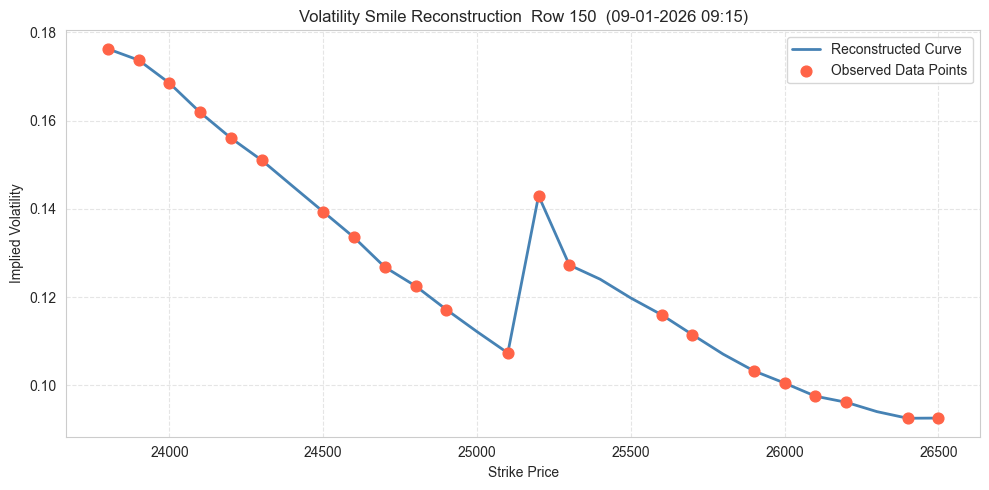

Row 150: 22 observed, 6 reconstructed out of 28 contracts.


In [21]:
#  Qualitative check: reconstructed smile vs. observed points 
# A sanity check that the reconstructed curve actually passes smoothly through
# the observed data and interpolates the gaps sensibly.

import matplotlib.pyplot as plt

def get_strike_from_col(col_name):
    match = re.search(r'(\d{5})(CE|PE)', col_name)
    return int(match.group(1)) if match else None

df_original = df_raw.copy()
df_filled   = final_filled_df.copy()

row_idx = 150  # pick any representative timestamp

row_orig   = df_original.iloc[row_idx]
row_filled = df_filled.iloc[row_idx]

orig_pts   = [(get_strike_from_col(c), row_orig[c])   for c in iv_cols if not pd.isna(row_orig[c])]
filled_pts = [(get_strike_from_col(c), row_filled[c]) for c in iv_cols]
orig_pts.sort(key=lambda x: x[0])
filled_pts.sort(key=lambda x: x[0])

fig, ax = plt.subplots(figsize=(10, 5))

f_strikes, f_ivs = zip(*filled_pts)
ax.plot(f_strikes, f_ivs, color='steelblue', linestyle='-', linewidth=2, label='Reconstructed Curve')

o_strikes, o_ivs = zip(*orig_pts)
ax.scatter(o_strikes, o_ivs, color='tomato', zorder=5, s=60, label='Observed Data Points')

dt_label = df_original.iloc[row_idx]['datetime']
ax.set_title(f'Volatility Smile Reconstruction  Row {row_idx}  ({dt_label})')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Implied Volatility')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Missingness annotation
n_observed = sum(1 for c in iv_cols if not pd.isna(row_orig[c]))
n_missing  = len(iv_cols) - n_observed
print(f"Row {row_idx}: {n_observed} observed, {n_missing} reconstructed out of {len(iv_cols)} contracts.")

---
## Summary of Results

| Approach | Method | Leaderboard MSE |
|----------|--------|-----------------|
| 1 | PCHIP + LightGBM Residual | 0.002748 |
| 2 | Pure PCHIP + ffill | 0.011225 |
| 3 | PCHIP + Flat Wings | 0.001045 |
| 4 | Regime PCHIP / Linear | 0.000430 |
| 5 | Regime PCHIP / Linear + CV | 0.001037 |
| 6 | Natural Spline / Linear + CV | 0.0000431 |
| 7 | Weighted Poly + PCHIP Hybrid | 0.0000337 |

### Key Takeaways

- Math > ML for smooth surfaces.
- Local adaptation beats global fitting. 
- Wing treatment is everything. The final improvement came from better wing extrapolation.
- Lookahead bias is strictly avoided. All temporal operations use past data only.
